# Markov Chain Weather Toy Notebook

This notebook uses one small weather-state Markov chain to teach five connected ideas:

1. Markov chains
2. Transition probabilities and the transition matrix
3. Monte Carlo simulation of state paths
4. Final-state distributions
5. Convergence of empirical distributions to theoretical distributions

The example is intentionally small and interpretable:

- State 0 = Sunny
- State 1 = Cloudy
- State 2 = Rainy

We will use the same three-state chain throughout. The goal is not clever code. The goal is to make the transition logic, the simulation logic, and the distribution comparison visually clear.

## Section 1 - Problem setup

We model daily weather as a sequence of states. On each day, the weather is in exactly one of three categories:

- Sunny
- Cloudy
- Rainy

A **discrete-time finite-state Markov chain** is a stochastic process that moves between such states over time.

Here our state process is

$$S_0, S_1, S_2, \ldots$$

with state space

$$\mathcal{S} = \{0,1,2\} = \{\text{Sunny}, \text{Cloudy}, \text{Rainy}\}. $$

The transition matrix is

$$
P = \begin{bmatrix}
0.70 & 0.20 & 0.10 \\
0.30 & 0.40 & 0.30 \\
0.20 & 0.30 & 0.50
\end{bmatrix}.
$$

This matrix is **row-stochastic**, which means:

- every entry is nonnegative
- each row sums to 1

That matters because each row is a full probability distribution over tomorrow's weather, given today's weather.

We start deterministically in the Sunny state, so the initial distribution is

$$\pi_0 = [1,0,0].$$

One simulation replication means one possible weather path:

$$S_0 \rightarrow S_1 \rightarrow S_2 \rightarrow \cdots \rightarrow S_T.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

SEED = 20260411
state_labels = ['Sunny', 'Cloudy', 'Rainy']


def simulate_markov_chain(P, initial_state, T, rng):
    """Simulate one Markov-chain path of length T."""
    path = np.empty(T + 1, dtype=int)
    path[0] = initial_state
    for t in range(T):
        current_state = path[t]
        path[t + 1] = rng.choice(P.shape[0], p=P[current_state])
    return path


def simulate_many_paths(P, initial_state, T, n_paths, seed):
    """Simulate many independent paths."""
    rng = np.random.default_rng(seed)
    paths = np.empty((n_paths, T + 1), dtype=int)
    for i in range(n_paths):
        paths[i] = simulate_markov_chain(P, initial_state, T, rng)
    return paths


def empirical_final_distribution(final_states, n_states):
    """Estimate the final-state distribution by relative frequencies."""
    counts = np.bincount(final_states, minlength=n_states)
    return counts / len(final_states)


def theoretical_final_distribution(pi0, P, T):
    """Compute pi_T = pi_0 P^T."""
    return pi0 @ np.linalg.matrix_power(P, T)


def propagate_distribution_path(pi0, P, T):
    """Return pi_0, pi_1, ..., pi_T under repeated matrix propagation."""
    distributions = np.empty((T + 1, len(pi0)))
    distributions[0] = pi0
    current = pi0.copy()
    for t in range(1, T + 1):
        current = current @ P
        distributions[t] = current
    return distributions


def l1_distance(p, q):
    """L1 distance between two probability vectors."""
    return np.sum(np.abs(p - q))


def running_event_probability(final_states, target_state):
    """Running estimate of a final-state event probability."""
    indicators = (final_states == target_state).astype(float)
    return np.cumsum(indicators) / np.arange(1, len(indicators) + 1)

In [2]:
# Core model inputs.
P = np.array([
    [0.70, 0.20, 0.10],
    [0.30, 0.40, 0.30],
    [0.20, 0.30, 0.50],
])
pi0 = np.array([1.0, 0.0, 0.0])
initial_state = 0
T_path = 20
T_final = 12
n_paths_main = 2000

# Sanity checks for row-stochasticity.
row_sums = P.sum(axis=1)
assert np.all(P >= 0.0)
assert np.allclose(row_sums, 1.0)

print('State labels:', state_labels)
print('Transition matrix P:')
print(P)
print('\nRow sums:', row_sums)
print('Initial distribution pi_0 =', pi0)
print('Initial weather state =', initial_state, '(', state_labels[initial_state], ')')

State labels: ['Sunny', 'Cloudy', 'Rainy']
Transition matrix P:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]

Row sums: [1. 1. 1.]
Initial distribution pi_0 = [1. 0. 0.]
Initial weather state = 0 ( Sunny )


## Section 2 - The Markov property

The **Markov property** says that once we know today's weather state, we do not need the full earlier history to describe tomorrow's weather distribution:

$$\Pr(S_{t+1}=j \mid S_t=i, S_{t-1}, \ldots, S_0) = \Pr(S_{t+1}=j \mid S_t=i).$$

Plain English:

- the next day depends on the current weather state
- the full past matters only through the current state

The entry

$$P_{ij} = \Pr(S_{t+1}=j \mid S_t=i)$$

is the probability of moving from current weather state $i$ to next-day weather state $j$.

So row $i$ tells us the full next-day weather distribution when today is state $i$.

That is why it is helpful to say:

> today's row gives tomorrow's law

If today is Sunny, tomorrow's weather distribution is [0.7 0.2 0.1]
If today is Cloudy, tomorrow's weather distribution is [0.3 0.4 0.3]
If today is Rainy, tomorrow's weather distribution is [0.2 0.3 0.5]


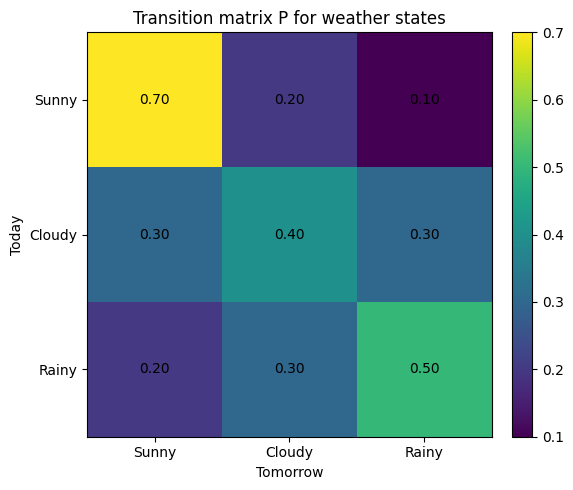

In [3]:
# Row-by-row interpretation of the transition matrix.
for i, label in enumerate(state_labels):
    print(f'If today is {label}, tomorrow\'s weather distribution is {P[i]}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(P)
ax.set_xticks(range(len(state_labels)))
ax.set_yticks(range(len(state_labels)))
ax.set_xticklabels(state_labels)
ax.set_yticklabels(state_labels)
ax.set_xlabel('Tomorrow')
ax.set_ylabel('Today')
ax.set_title('Transition matrix P for weather states')

for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        ax.text(j, i, f'{P[i, j]:.2f}', ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Section 3 - Simulating one path

One simulation replication means one possible weather path.

The simulation logic is step by step:

1. observe the current weather state
2. take the corresponding row of $P$
3. sample tomorrow's state from that row
4. repeat

So the mechanism is local and recursive:

> current weather -> current row -> next-day draw

Realized weather path:
['Sunny', 'Sunny', 'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Rainy', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Sunny']


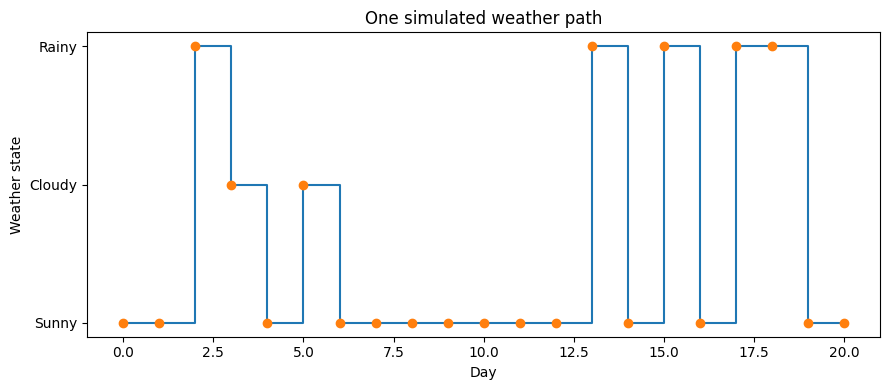

In [4]:
rng = np.random.default_rng(SEED + 1)
single_path = simulate_markov_chain(P, initial_state, T_path, rng)
single_path_labels = [state_labels[s] for s in single_path]

print('Realized weather path:')
print(single_path_labels)

plt.figure(figsize=(9, 4))
plt.step(range(T_path + 1), single_path, where='post')
plt.plot(range(T_path + 1), single_path, marker='o', linestyle='None')
plt.yticks([0, 1, 2], state_labels)
plt.xlabel('Day')
plt.ylabel('Weather state')
plt.title('One simulated weather path')
plt.tight_layout()
plt.show()

## Section 4 - Monte Carlo estimation of the final-day weather distribution

Now we move from one path to many paths.

Fix a horizon $T$. Each simulation replication gives one realized final weather state $S_T$.

If we simulate many independent weather paths and record their final states, we can estimate the final-state distribution by relative frequencies:

$$\hat \pi_T(j) = \frac{1}{N} \sum_{i=1}^N \mathbf{1}\{S_T^{(i)} = j\}. $$

This is a Monte Carlo estimate because it is built by averaging over many random replications.

Horizon T = 12
Number of Monte Carlo paths N = 2000
Empirical final-day weather distribution = [0.4195 0.305  0.2755]


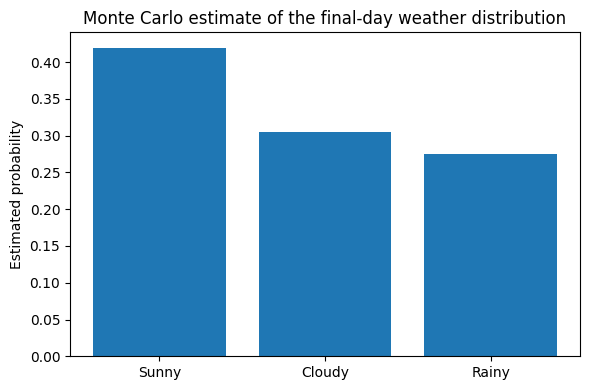

In [5]:
paths = simulate_many_paths(P, initial_state, T_final, n_paths_main, seed=SEED + 2)
final_states = paths[:, -1]
empirical_pi_T = empirical_final_distribution(final_states, n_states=P.shape[0])

print(f'Horizon T = {T_final}')
print(f'Number of Monte Carlo paths N = {n_paths_main}')
print('Empirical final-day weather distribution =', empirical_pi_T)

plt.figure(figsize=(6, 4))
plt.bar(state_labels, empirical_pi_T)
plt.ylabel('Estimated probability')
plt.title('Monte Carlo estimate of the final-day weather distribution')
plt.tight_layout()
plt.show()

## Section 5 - Theoretical final-state distribution

For a finite-state Markov chain, we can also compute the exact final-state distribution by matrix multiplication.

If the initial distribution is $\pi_0$, then after $T$ steps the theoretical distribution is

$$\pi_T = \pi_0 P^T.$$

This gives the exact model-implied weather distribution on day $T$.

We now compare:

- the theoretical final-day distribution
- the empirical Monte Carlo estimate

Theoretical final-day distribution pi_T = [0.45658527 0.28259167 0.26082306]
Empirical Monte Carlo estimate      = [0.4195 0.305  0.2755]
L1 distance between them = 0.0742


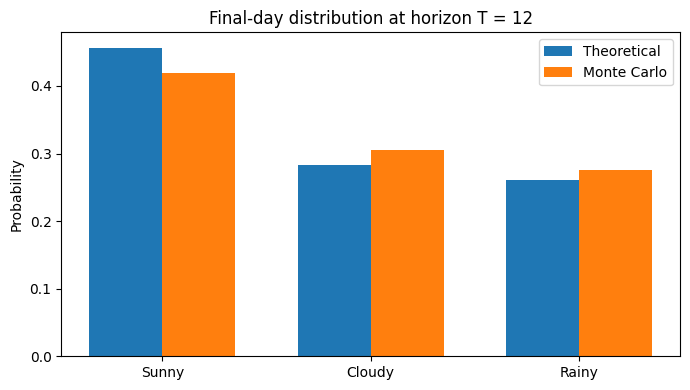

In [8]:
theoretical_pi_T = theoretical_final_distribution(pi0, P, T_final)
distance_main = l1_distance(empirical_pi_T, theoretical_pi_T)

print('Theoretical final-day distribution pi_T =', theoretical_pi_T)
print('Empirical Monte Carlo estimate      =', empirical_pi_T)
print(f'L1 distance between them = {distance_main:.4f}')

x = np.arange(len(state_labels))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, theoretical_pi_T, width=width, label='Theoretical')
plt.bar(x + width / 2, empirical_pi_T, width=width, label='Monte Carlo')
plt.xticks(x, state_labels)
plt.ylabel('Probability')
plt.title(f'Final-day distribution at horizon T = {T_final}')
plt.legend()
plt.tight_layout()
plt.show()

## Section 6 - LLN-style stabilization

Let us focus on one event:

$$\Pr(S_T = \text{Rainy}).$$

Each simulated path either ends in Rainy or it does not. So this is again an average of indicator variables.

By the Law of Large Numbers, as the number of simulated paths grows, the running estimate should stabilize around the theoretical probability.

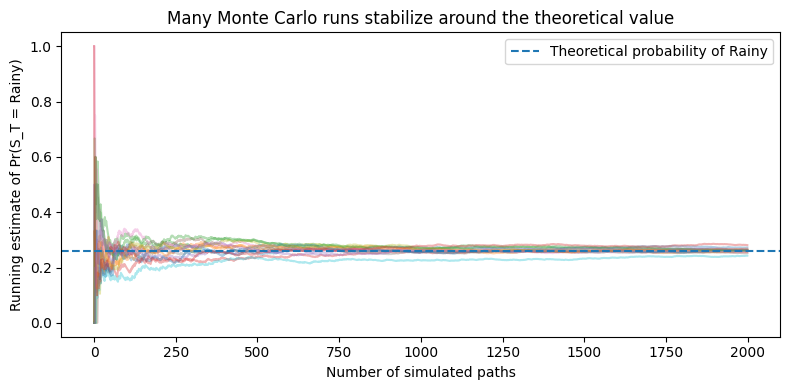

Theoretical Pr(S_T = Rainy) at T = 12: 0.2608


In [9]:
target_state = 2
n_runs = 15
n_paths_lln = 2000
theoretical_rainy_prob = theoretical_pi_T[target_state]

plt.figure(figsize=(8, 4))
for run in range(n_runs):
    run_paths = simulate_many_paths(P, initial_state, T_final, n_paths_lln, seed=SEED + 100 + run)
    run_final_states = run_paths[:, -1]
    running_estimate = running_event_probability(run_final_states, target_state)
    plt.plot(running_estimate, alpha=0.35)

plt.axhline(theoretical_rainy_prob, linestyle='--', label='Theoretical probability of Rainy')
plt.xlabel('Number of simulated paths')
plt.ylabel('Running estimate of Pr(S_T = Rainy)')
plt.title('Many Monte Carlo runs stabilize around the theoretical value')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Theoretical Pr(S_T = Rainy) at T = {T_final}: {theoretical_rainy_prob:.4f}')

## Section 7 - Distribution convergence

Now we compare the full final-day distribution for several replication counts:

$$N \in \{10, 50, 200, 1000\}. $$

As $N$ grows, Monte Carlo noise should shrink and the empirical distribution should move closer to the theoretical benchmark.

To make that visible, we will:

- show representative empirical-versus-theoretical bar charts
- compute an $L_1$ distance
- average that distance over many repeated Monte Carlo experiments

N =   10 | representative empirical distribution = [0.3 0.3 0.4] | L1 distance = 0.3132


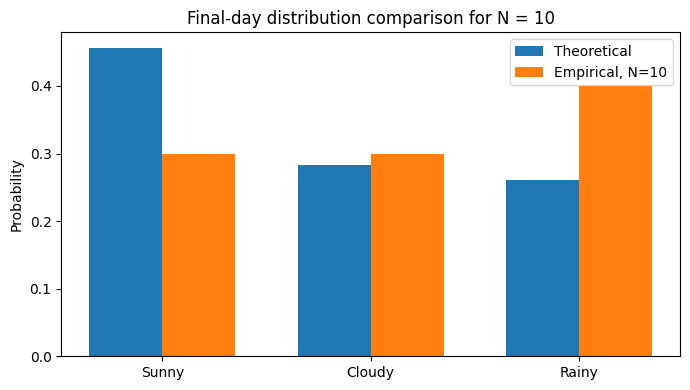

N =   50 | representative empirical distribution = [0.46 0.16 0.38] | L1 distance = 0.2452


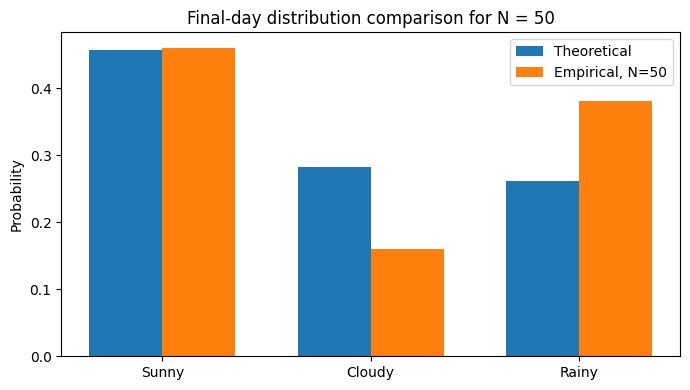

N =  200 | representative empirical distribution = [0.475 0.28  0.245] | L1 distance = 0.0368


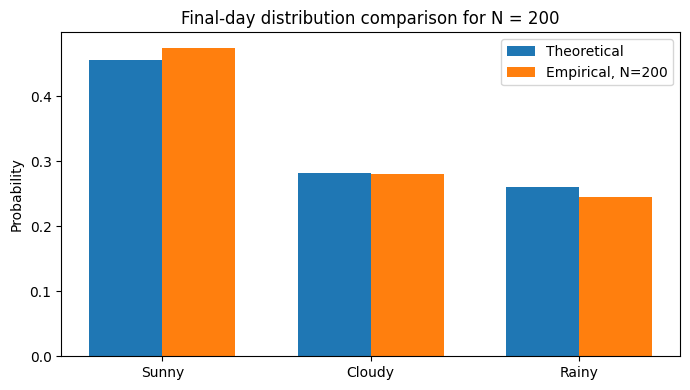

N = 1000 | representative empirical distribution = [0.441 0.28  0.279] | L1 distance = 0.0364


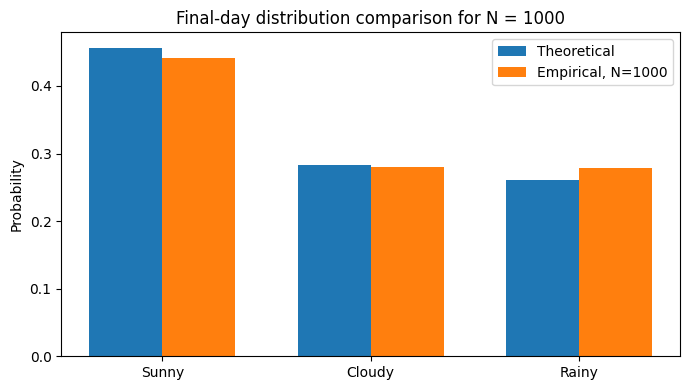


Average L1 distance over 300 repeated experiments:
N =   10 | mean L1 distance = 0.3606
N =   50 | mean L1 distance = 0.1613
N =  200 | mean L1 distance = 0.0745
N = 1000 | mean L1 distance = 0.0347


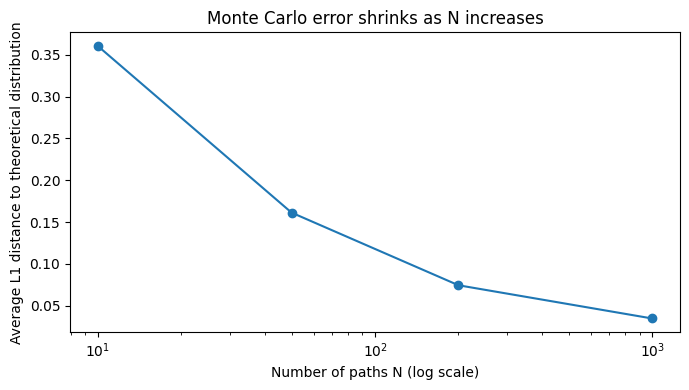

In [10]:
N_values = [10, 50, 200, 1000]
mean_distances = []

for idx, N in enumerate(N_values):
    sample_paths = simulate_many_paths(P, initial_state, T_final, N, seed=SEED + 200 + idx)
    sample_final = sample_paths[:, -1]
    empirical_dist = empirical_final_distribution(sample_final, n_states=P.shape[0])
    representative_distance = l1_distance(empirical_dist, theoretical_pi_T)

    print(f'N = {N:4d} | representative empirical distribution = {empirical_dist} | L1 distance = {representative_distance:.4f}')

    x = np.arange(len(state_labels))
    width = 0.35
    plt.figure(figsize=(7, 4))
    plt.bar(x - width / 2, theoretical_pi_T, width=width, label='Theoretical')
    plt.bar(x + width / 2, empirical_dist, width=width, label=f'Empirical, N={N}')
    plt.xticks(x, state_labels)
    plt.ylabel('Probability')
    plt.title(f'Final-day distribution comparison for N = {N}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    distances = []
    for rep in range(300):
        rep_paths = simulate_many_paths(P, initial_state, T_final, N, seed=SEED + 1000 * idx + rep)
        rep_final = rep_paths[:, -1]
        rep_empirical = empirical_final_distribution(rep_final, n_states=P.shape[0])
        distances.append(l1_distance(rep_empirical, theoretical_pi_T))
    mean_distances.append(np.mean(distances))

print('\nAverage L1 distance over 300 repeated experiments:')
for N, d in zip(N_values, mean_distances):
    print(f'N = {N:4d} | mean L1 distance = {d:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(N_values, mean_distances, marker='o')
plt.xscale('log')
plt.xlabel('Number of paths N (log scale)')
plt.ylabel('Average L1 distance to theoretical distribution')
plt.title('Monte Carlo error shrinks as N increases')
plt.tight_layout()
plt.show()

## Section 8 - Optional stationary intuition

A useful intuition is that repeated application of the same transition matrix may gradually push different initial distributions toward a similar long-run pattern.

We keep this visual and simple. Start once from Sunny and once from Rainy, then propagate both distributions forward by matrix multiplication.

In [ ]:
pi0_sunny = np.array([1.0, 0.0, 0.0])
pi0_rainy = np.array([0.0, 0.0, 1.0])
T_long = 25

dist_path_sunny = propagate_distribution_path(pi0_sunny, P, T_long)
dist_path_rainy = propagate_distribution_path(pi0_rainy, P, T_long)
distribution_gap = np.sum(np.abs(dist_path_sunny - dist_path_rainy), axis=1)

print('Distribution after 25 steps when starting from Sunny:', dist_path_sunny[-1])
print('Distribution after 25 steps when starting from Rainy:', dist_path_rainy[-1])

plt.figure(figsize=(8, 4))
plt.plot(dist_path_sunny[:, 2], label='Pr(S_t = Rainy), start Sunny')
plt.plot(dist_path_rainy[:, 2], label='Pr(S_t = Rainy), start Rainy')
plt.xlabel('Day')
plt.ylabel('Probability of Rainy')
plt.title('Different starts move toward similar long-run behavior')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(distribution_gap, marker='o')
plt.xlabel('Day')
plt.ylabel('L1 distance between the two propagated distributions')
plt.title('The propagated distributions become more similar over time')
plt.tight_layout()
plt.show()

## Section 9 - Connect the ideas

| Concept | Main idea | In this notebook |
| --- | --- | --- |
| Markov chain | Stochastic evolution where the current state summarizes the relevant past | Weather moves between Sunny, Cloudy, and Rainy |
| Transition matrix | Local mechanism of state movement | Row $i$ gives tomorrow's weather law from today's state $i$ |
| Monte Carlo | Simulate many possible weather paths | We generate many independent paths up to horizon $T$ |
| Empirical distribution | Simulated estimate | Relative frequencies of the observed final-day states |
| Theoretical distribution | Matrix-based benchmark | $\pi_T = \pi_0 P^T$ |

A useful memory hook is:

- one path = one possible weather world
- one row of $P$ tells us how tomorrow is generated from today
- many paths reveal the distribution of future weather states

## Section 10 - Final takeaway

- One weather path is one possible world.
- The transition matrix defines how the weather system moves.
- Many paths estimate future weather-state probabilities.
- Empirical frequencies stabilize with more replications.
- Matrix propagation gives an exact benchmark, while Monte Carlo gives a simulation-based approximation.

## Teaching notes

### Likely misunderstandings

- One often mixes up one realized weather path with the full distribution over many possible paths.
- One often confuses a row of $P$ with the full-horizon distribution $\pi_0 P^T$.
- One might think the Markov property means the past is irrelevant in every sense. The better interpretation is that the past matters only through the current state representation.
- One might think Monte Carlo changes the model. It does not. It is a numerical way to approximate the implications of the same transition model.

### What each plot is intended to teach

- The matrix plot teaches that each row is a next-day weather distribution.
- The single-path plot teaches what one simulation replication actually is.
- The empirical final-distribution plot teaches that final-state probabilities can be estimated by relative frequencies.
- The theoretical-versus-empirical bar chart teaches that Monte Carlo should approximate the exact matrix-based benchmark.
- The LLN-style running plot teaches stabilization of an estimated event probability.
- The convergence plots teach that Monte Carlo error shrinks as the number of paths grows.
- The optional long-run extension teaches that repeated application of the same transition matrix can reduce the importance of the initial state.

### What toemphasize

- Emphasize the phrase: current state -> current row -> next-day draw.
- Keep the distinction clear between one-step transition logic and long-horizon distribution propagation.
- When introducing $\pi_0 P^T$, emphasize that it is a distribution, not a realized path.
- Emphasize that Monte Carlo error is sampling noise, not model error.
- Use the weather story to make the state idea intuitive before students see more abstract sequential models.